In [ ]:
!pip install qiskit-ibm-runtime
!pip install 'qiskit[visualization]'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.circuit.library import RealAmplitudes
from qiskit.circuit.library import QAOAAnsatz
from qiskit.circuit.library import hamiltonian_variational_ansatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit import QuantumCircuit, Parameter

from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

from qiskit.quantum_info import Statevector

from math import pi

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [ ]:
!pip install qiskit-aer
from qiskit_aer import AerSimulator
backend=AerSimulator()

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

# **Looped 2 Qubit Ising Model (Quantum)**

In [ ]:
#graph of h vs E (initialized groups)
optimized_x = []
optimal_fun = []
num_func_evals = []
max_constraint_violation = []
success_flag =[]
message = []

ideal_gs_energy = []

In [ ]:
h_val = [-2, -1.75,-1.5,-1.25,-1,-0.75,-0.5,-0.25,0, 0.25, 0.5, 0.75, 1,1.25,1.5,1.75,2]
h_values = np.arange(-2,2.1,0.05)

In [ ]:
#create cost function
def cost_function(params, ansatz, hamiltonian, estimator):
  pub = (ansatz, [hamiltonian],[params])
  result = estimator.run(pubs=[pub]).result()
  energy=result[0].data.evs[0]

  cost_history_dict["iters"] +=1
  cost_history_dict["prev_vector"] = params
  cost_history_dict["cost_history"].append(energy)
  print(f"Iters.done: {cost_history_dict['iters']} [Current Cost: {energy}]")

  return energy

In [ ]:
for h in h_values:
  #Hamiltonian Define
  # H=ZZ
  J=1
  hamil = SparsePauliOp.from_list([("ZZ",-J),("XI",h),("IX",h)])
  hamiltonian = sum(hamil)
  #print(hamiltonian)

  #Finding eigenvalues/vectors
  print("THE EIGENSTUFF")
  eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian.to_matrix())
  print("Eigenvalues:")
  for eigenvalue in eigenvalues:
      print(eigenvalue)

  print("\n Eigenstates:")
  for eigenvector in eigenvectors:
      print(Statevector(eigenvector))
  ideal_gs_energy.append(eigenvalues[0])
  #print(ideal_gs_energy)

  #Define ansatz
  ansatz = efficient_su2(hamiltonian.num_qubits)
  #ansatz.decompose().draw("mpl", style = "iqp")

  #Determine number of parameters
  num_params = ansatz.num_parameters
  print(num_params)

  #adjust ansatz to isa form (for ease of simulation)
  ansatz_isa = pm.run(ansatz)
  #ansatz_isa.draw(output="mpl", idle_wires=False, style = "iqp")

  hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

  cost_history_dict = {"prev_vector":None, "iters": 0, "cost_history":[]}

  #initial parameters - randomized initially
  x0 = 2 * np.pi * np.random.random(num_params)

  #the simulation
  with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots=10000

    res = minimize( cost_function, x0, args = (ansatz_isa, hamiltonian_isa, estimator), method="cobyla")

  print(res)

  all(cost_history_dict["prev_vector"]==res.x)

  cost_history_dict["iters"]==res.nfev

  #h_values=[-2,-1.75,-1.5,-1.25,-1,-0.75,-0.5,-0.25,0] # This line is redundant
  optimized_x.append(res.x)
  optimal_fun.append(res.fun)
  num_func_evals.append(res.nfev)
  max_constraint_violation.append(res.maxcv)
  success_flag.append(res.success)
  message.append(res.message)


Streaming output truncated to the last 5000 lines.
Iters.done: 131 [Current Cost: -1.5981400000000026]
Iters.done: 132 [Current Cost: -1.6033300000000028]
Iters.done: 133 [Current Cost: -1.6005000000000027]
Iters.done: 134 [Current Cost: -1.5788700000000027]
Iters.done: 135 [Current Cost: -1.5768000000000026]
Iters.done: 136 [Current Cost: -1.5932000000000028]
Iters.done: 137 [Current Cost: -1.5998800000000026]
Iters.done: 138 [Current Cost: -1.5842900000000026]
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.624580000000003
       x: [ 3.895e+00  1.256e+00 ...  5.384e+00  8.698e-01]
    nfev: 138
   maxcv: 0.0
THE EIGENSTUFF
Eigenvalues:
-1.7204650534085293
-1.0
1.0
1.720465053408529

 Eigenstates:
Statevector([-6.28736470e-01+0.j,  7.07106781e-01+0.j, -1.11022302e-16+0.j,
              3.23559039e-01-0.j],
            dims=(2, 2))
Statevector([ 3.23559039e-01+0.j, -8.95443355e-17+0.j, -7.07106781e-01+0.j,
 

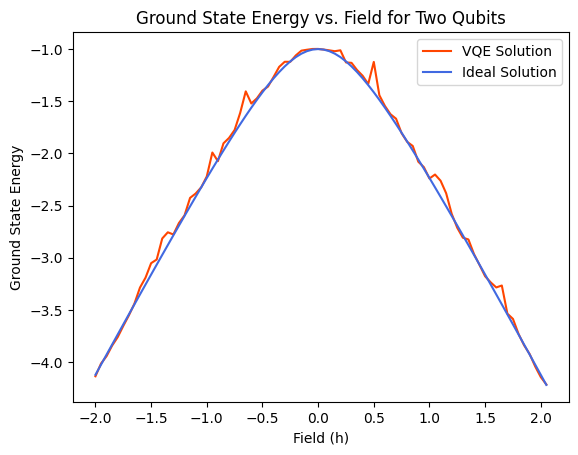

In [ ]:
import scipy, pylab
ax = pylab.subplot(111)
ax.plot(h_values, optimal_fun, "orangered", linewidth = 1.5)
ax.plot(h_values, ideal_gs_energy, "royalblue", linewidth = 1.5)
plt.title("Ground State Energy vs. Field for Two Qubits")
plt.xlabel("Field (h)")
plt.ylabel("Ground State Energy")
plt.legend(["VQE Solution", "Ideal Solution"])
ax.figure.show()

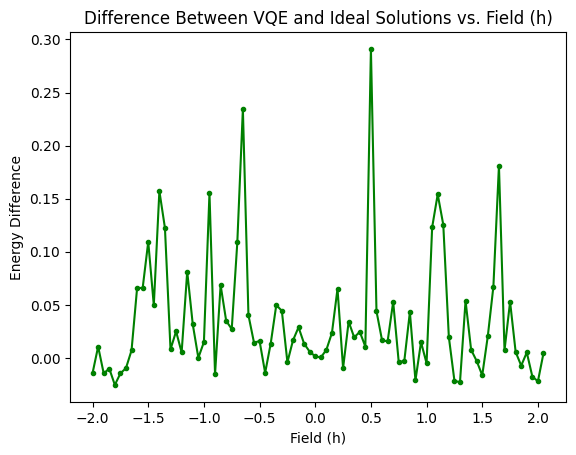

In [ ]:
# Calculate the difference between VQE solution and ideal solution
energy_difference = [vqe - ideal for vqe, ideal in zip(optimal_fun, ideal_gs_energy)]

# Plot the difference
ax = pylab.subplot(111)
ax.plot(h_values, energy_difference, "green", marker = '.', linewidth = 1.5)
plt.title("Difference Between VQE and Ideal Solutions vs. Field (h)")
plt.xlabel("Field (h)")
plt.ylabel("Energy Difference")
ax.figure.show()